# CGCNN Training and Visualization

This notebook implements the complete training pipeline for **Crystal Graph Convolutional Neural Networks (CGCNN)**, a deep learning framework for predicting material properties directly from crystal structures.

## Reference
**Paper**: Xie, T., & Grossman, J. C. (2018). "Crystal Graph Convolutional Neural Networks for an Accurate and Interpretable Prediction of Material Properties." *Physical Review Letters*, 120(14), 145301.

## Overview

CGCNN treats crystal structures as graphs where:
- **Nodes**: Represent atoms in the crystal
- **Edges**: Represent interactions between neighboring atoms
- **Node Features**: Atom properties (element type, electron configuration, etc.)
- **Edge Features**: Interatomic distances encoded as Gaussian basis functions

The network learns to predict material properties (e.g., formation energy, band gap) through:
1. **Graph Construction**: Converting crystal structures to graph representations
2. **Message Passing**: Aggregating information from neighboring atoms through multiple convolutional layers
3. **Pooling**: Combining atom-level features into crystal-level representation
4. **Prediction**: Mapping crystal features to target properties

## Workflow
1. Load the dataset created in notebook 02
2. Define data loading and model architectures
3. Train the model with proper tracking and validation
4. Evaluate performance on test set
5. Visualize training progress and prediction quality
6. Save model checkpoints and results

---

## Part 1: Setup and Imports

In [1]:
# Standard library imports
import os
import csv
import json
import random
import functools
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataloader import default_collate
from torch.utils.data.sampler import SubsetRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Pymatgen
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element

# Set random seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")


✅ All libraries imported successfully
PyTorch Version: 2.11.0+cpu
CUDA Available: False


## Part 2: Configuration

In [2]:
# Dataset Configuration
DATA_DIR = 'cif_structures'
MAX_NUM_NBR = 12
RADIUS = 8.0
DMIN = 0
DSTEP = 0.2

# Data Loading Configuration
BATCH_SIZE = 8
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Model Configuration
ATOM_FEA_LEN = 64
N_CONV = 3
H_FEA_LEN = 128
N_H = 1

LEARNING_RATE = 0.1
WEIGHT_DECAY = 0.0
EPOCHS = 5
EARLY_STOPPING_PATIENCE = 30

# Output Configuration
OUTPUT_DIR = 'training_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration:")
print(f"  data Directory: {DATA_DIR}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Train/Val/Test Split: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"  Model: {N_CONV} conv layers, {ATOM_FEA_LEN}D atom features, {H_FEA_LEN}D hidden")
print(f"  Output Directory: {OUTPUT_DIR}")


Configuration:
  data Directory: cif_structures
  Batch Size: 8
  Train/Val/Test Split: 0.7/0.15/0.15
  Model: 3 conv layers, 64D atom features, 128D hidden
  Output Directory: training_results


## Part 3: Data Loading Classes

These classes handle crystal structure loading and graph construction.

### Theoretical Background

#### 1. Gaussian Distance Expansion
Interatomic distances are encoded using **Gaussian basis functions** to create continuous, differentiable edge features:

$$
e_{ij}^k = \exp\left(-\frac{(d_{ij} - \mu_k)^2}{\sigma^2}\right)
$$

Where:
- $d_{ij}$: Distance between atoms $i$ and $j$
- $\mu_k$: Center of the $k$-th Gaussian filter
- $\sigma$: Width of the Gaussian (controls smoothness)

This expansion converts a single distance value into a vector of features, allowing the network to learn distance-dependent interactions.

#### 2. Atom Feature Initialization
Each atom is represented by a learnable feature vector based on its element type. These initial features capture:
- Element properties (atomic number, electronegativity, etc.)
- Electron configuration
- Chemical characteristics

#### 3. Crystal Graph Dataset
The dataset loads crystal structures from CIF (Crystallographic Information File) format and constructs graph representations:
- **Input**: CIF files + target properties (e.g., formation energy)
- **Output**: Graph tuple (atom_features, edge_features, edge_indices) + target value

#### 4. Batching Strategy
Since crystals have varying numbers of atoms, we use a custom collating function that:
1. Concatenates all atoms from different crystals into a single large graph
2. Maintains indices to track which atoms belong to which crystal
3. Enables efficient batch processing on GPU

In [3]:
class GaussianDistance(object):
    """Expands interatomic distances using Gaussian basis functions."""
    def __init__(self, dmin, dmax, step, var=None):
        assert dmin < dmax
        assert dmax - dmin > step
        self.filter = np.arange(dmin, dmax+step, step)
        if var is None:
            var = step
        self.var = var

    def expand(self, distances):
        diff = distances[..., np.newaxis] - self.filter
        squared_diff = diff ** 2
        var_squared = self.var ** 2
        result = np.exp(-squared_diff / var_squared)
        return result

class AtomInitializer(object):
    """Base class for initializing atom feature vectors."""
    def __init__(self, atom_types):
        self.atom_types = set(atom_types)
        self._embedding = {}

    def get_atom_fea(self, atom_type):
        assert atom_type in self.atom_types
        return self._embedding[atom_type]

    def load_state_dict(self, state_dict):
        self._embedding = state_dict
        self.atom_types = set(self._embedding.keys())

    def state_dict(self):
        return self._embedding

class AtomCustomJSONInitializer(AtomInitializer):
    """Initialize atom features from a JSON file."""
    def __init__(self, elem_embedding_file):
        with open(elem_embedding_file) as f:
            elem_embedding = json.load(f)
            
        if 'embeddings' in elem_embedding:
            elem_embedding = elem_embedding['embeddings']
        
        converted_embedding = {}
        for key, value in elem_embedding.items():
            try:
                atomic_num = int(key)
            except ValueError:
                try:
                    atomic_num = Element(key).Z
                except Exception as e:
                    print(f"Warning: Could not process element '{key}': {e}")
                    continue
            converted_embedding[atomic_num] = value
        
        atom_types = set(converted_embedding.keys())
        super(AtomCustomJSONInitializer, self).__init__(atom_types)
        
        for key, value in converted_embedding.items():
            self._embedding[key] = np.array(value, dtype=float)

class CIFData(Dataset):
    """PyTorch Dataset for crystal structures stored as CIF files."""
    def __init__(self, root_dir, max_num_nbr=12, radius=8, dmin=0, step=0.2, random_seed=123):
        self.root_dir = root_dir
        self.max_num_nbr, self.radius = max_num_nbr, radius
        
        assert os.path.exists(root_dir), f'root_dir does not exist: {root_dir}'

        id_prop_file = 'id_prop.csv'
        if not os.path.exists(id_prop_file):
            id_prop_file = os.path.join(self.root_dir, 'id_prop.csv')
        assert os.path.exists(id_prop_file), f'id_prop.csv not found at {id_prop_file}'

        with open(id_prop_file) as f:
            reader = csv.reader(f)
            self.id_prop_data = [(row[0], float(row[1])) for row in reader]
        random.seed(random_seed)
        random.shuffle(self.id_prop_data)
        
        atom_init_file = 'atom_embedding.json'
        if not os.path.exists(atom_init_file):
            atom_init_file = os.path.join(self.root_dir, 'atom_embedding.json')
        assert os.path.exists(atom_init_file), f'atom_embedding.json not found at {atom_init_file}'
        
        self.ari = AtomCustomJSONInitializer(atom_init_file)
        self.gdf = GaussianDistance(dmin=dmin, dmax=self.radius, step=step)

    def __len__(self):
        return len(self.id_prop_data)

    @functools.lru_cache(maxsize=None)
    def __getitem__(self, idx):
        cif_id, target = self.id_prop_data[idx]
        cif_path = os.path.join(self.root_dir, cif_id+'.cif')
        crystal = Structure.from_file(cif_path)
        
        atom_fea = np.vstack([self.ari.get_atom_fea(crystal[i].specie.number)
                              for i in range(len(crystal))])
        atom_fea = torch.Tensor(atom_fea)
        
        all_nbrs = crystal.get_all_neighbors(self.radius, include_index=True)
        all_nbrs = [sorted(nbrs, key=lambda x: x[1]) for nbrs in all_nbrs]
        
        nbr_fea_idx, nbr_fea = [], []
        for nbr in all_nbrs:
            if len(nbr) < self.max_num_nbr:
                warnings.warn(f'{cif_id}: not enough neighbors')
                nbr_fea_idx.append(list(map(lambda x: x[2], nbr)) + [0] * (self.max_num_nbr - len(nbr)))
                nbr_fea.append(list(map(lambda x: x[1], nbr)) + [self.radius + 1.] * (self.max_num_nbr - len(nbr)))
            else:
                nbr_fea_idx.append(list(map(lambda x: x[2], nbr[:self.max_num_nbr])))
                nbr_fea.append(list(map(lambda x: x[1], nbr[:self.max_num_nbr])))
        
        nbr_fea_idx, nbr_fea = np.array(nbr_fea_idx), np.array(nbr_fea)
        nbr_fea = self.gdf.expand(nbr_fea)
        
        return (torch.Tensor(atom_fea), torch.Tensor(nbr_fea), torch.LongTensor(nbr_fea_idx)), \
               torch.Tensor([float(target)]), cif_id

def collate_pool(dataset_list):
    """Collate function for batching variable-sized crystal graphs."""
    batch_atom_fea, batch_nbr_fea, batch_nbr_fea_idx = [], [], []
    crystal_atom_idx, batch_target = [], []
    batch_cif_ids = []
    base_idx = 0
    
    for i, ((atom_fea, nbr_fea, nbr_fea_idx), target, cif_id) in enumerate(dataset_list):
        n_i = atom_fea.shape[0]
        batch_atom_fea.append(atom_fea)
        batch_nbr_fea.append(nbr_fea)
        batch_nbr_fea_idx.append(nbr_fea_idx + base_idx)
        
        new_idx = torch.LongTensor(np.arange(n_i) + base_idx)
        crystal_atom_idx.append(new_idx)
        batch_target.append(target)
        batch_cif_ids.append(cif_id)
        base_idx += n_i
    
    return (torch.cat(batch_atom_fea, dim=0),
            torch.cat(batch_nbr_fea, dim=0),
            torch.cat(batch_nbr_fea_idx, dim=0),
            crystal_atom_idx), \
           torch.stack(batch_target, dim=0), \
           batch_cif_ids

def get_train_val_test_loader(dataset, collate_fn=default_collate,
                              batch_size=64, train_ratio=None,
                              val_ratio=0.1, test_ratio=0.1, return_test=False,
                              num_workers=0, pin_memory=False, **kwargs):
    """Create train, validation, and test data loaders with proper splitting."""
    total_size = len(dataset)
    if train_ratio is None:
        train_ratio = 1 - val_ratio - test_ratio
    
    indices = list(range(total_size))
    train_size = int(train_ratio * total_size)
    test_size = int(test_ratio * total_size)
    valid_size = int(val_ratio * total_size)
    
    train_sampler = SubsetRandomSampler(indices[:train_size])
    val_sampler = SubsetRandomSampler(indices[-(valid_size + test_size):-test_size])
    
    train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler,
                              num_workers=num_workers, collate_fn=collate_fn, pin_memory=pin_memory)
    val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler,
                            num_workers=num_workers, collate_fn=collate_fn, pin_memory=pin_memory)
    
    if return_test:
        test_sampler = SubsetRandomSampler(indices[-test_size:])
        test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler,
                                 num_workers=num_workers, collate_fn=collate_fn, pin_memory=pin_memory)
        return train_loader, val_loader, test_loader


## Part 4: Load Dataset and Create Data Loaders

### What Happens Here

This section:
1. **Loads the crystal dataset** from CIF files created in notebook 02
2. **Extracts feature dimensions** needed to initialize the model
3. **Creates data loaders** for efficient batch processing during training

### Key Information Extracted

- **ORIG_ATOM_FEA_LEN**: Dimension of input atom features (depends on atom_init.json)
- **NBR_FEA_LEN**: Dimension of edge features (= number of Gaussian filters)
  - Computed as: `(radius - dmin) / step + 1`
  - Example: `(8.0 - 0) / 0.2 + 1 = 41`

### Data Split Strategy

```
Total Dataset (100%)
    ├── Training Set (70%) → Used for weight updates
    ├── Validation Set (15%) → Used for hyperparameter tuning
    └── Test Set (15%) → Final performance evaluation
```

**Important**: Test set is never used during training or model selection!

In [4]:
# Test GaussianDistance class
print("\n" + "="*80)
print("Testing GaussianDistance Function")
print("="*80)
gdf_test = GaussianDistance(dmin=DMIN, dmax=RADIUS, step=DSTEP)
print(f"✅ GaussianDistance initialized:")
print(f"   Filter centers: {len(gdf_test.filter)} points")
print(f"   Distance range: {DMIN} to {RADIUS} Å")
print(f"   Step size: {DSTEP} Å")
print(f"   Variance: {gdf_test.var}")

# Test with sample distances
sample_distances = np.array([2.5, 3.0, 4.5, 5.5])
expanded_features = gdf_test.expand(sample_distances)
print(f"\n   Sample distances: {sample_distances}")
print(f"   Expanded shape: {expanded_features.shape}")
print(f"   Sample expanded features (first distance):\n{expanded_features[0, :5]}")

# Load dataset using CIFData class
print("\n" + "="*80)
print("Loading Dataset with CIFData Class")
print("="*80)
dataset = CIFData(
    root_dir=DATA_DIR,
    max_num_nbr=MAX_NUM_NBR,
    radius=RADIUS,
    dmin=DMIN,
    step=DSTEP,
    random_seed=RANDOM_SEED
)

print(f"✅ Dataset loaded successfully:")
print(f"   Total crystals: {len(dataset)}")

# Get first sample to verify structure
(atom_fea, nbr_fea, nbr_fea_idx), target, cif_id = dataset[0]
ORIG_ATOM_FEA_LEN = atom_fea.shape[1]
NBR_FEA_LEN = nbr_fea.shape[2]

print(f"   First crystal: {cif_id}")
print(f"   Number of atoms: {atom_fea.shape[0]}")
print(f"   Atom feature dimension: {ORIG_ATOM_FEA_LEN}")
print(f"   Max neighbors: {nbr_fea.shape[1]}")
print(f"   Neighbor feature dimension: {NBR_FEA_LEN}")
print(f"   Target property value: {target.item():.6f}")

# Create data loaders using get_train_val_test_loader
print("\n" + "="*80)
print("Creating Data Loaders with get_train_val_test_loader")
print("="*80)
train_loader, val_loader, test_loader = get_train_val_test_loader(
    dataset=dataset,
    collate_fn=collate_pool,
    batch_size=BATCH_SIZE,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    return_test=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"✅ Data loaders created successfully:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Training samples: {len(train_loader.dataset)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Validation samples: {len(val_loader.dataset)}")
print(f"   Test batches: {len(test_loader)}")
print(f"   Test samples: {len(test_loader.dataset)}")

# Test collate_pool function with first batch
print("\n" + "="*80)
print("Testing collate_pool Function")
print("="*80)
first_batch = next(iter(train_loader))
(batch_atom_fea, batch_nbr_fea, batch_nbr_fea_idx, crystal_atom_idx), batch_target, batch_cif_ids = first_batch

print(f"✅ Batch collated successfully:")
print(f"   Batch atom features shape: {batch_atom_fea.shape}")
print(f"   Batch neighbor features shape: {batch_nbr_fea.shape}")
print(f"   Batch neighbor indices shape: {batch_nbr_fea_idx.shape}")
print(f"   Number of crystals in batch: {len(crystal_atom_idx)}")
print(f"   Crystal atom indices (first crystal): {crystal_atom_idx[0]}")
print(f"   Batch target shape: {batch_target.shape}")
print(f"   Batch material IDs: {batch_cif_ids[:3]}...")  # Show first 3

# Save data loading summary
print("\n" + "="*80)
print("Saving Data Loading Summary")
print("="*80)

data_summary = {
    'GaussianDistance': {
        'filter_centers': len(gdf_test.filter),
        'distance_range': f'{DMIN} to {RADIUS} Å',
        'step_size': DSTEP,
        'variance': gdf_test.var
    },
    'Dataset': {
        'total_samples': len(dataset),
        'atom_feature_dimension': ORIG_ATOM_FEA_LEN,
        'neighbor_feature_dimension': NBR_FEA_LEN,
        'max_neighbors': MAX_NUM_NBR,
        'radius_cutoff': RADIUS
    },
    'DataLoaders': {
        'batch_size': BATCH_SIZE,
        'train_ratio': TRAIN_RATIO,
        'val_ratio': VAL_RATIO,
        'test_ratio': TEST_RATIO,
        'train_batches': len(train_loader),
        'val_batches': len(val_loader),
        'test_batches': len(test_loader),
        'train_samples': len(train_loader.dataset),
        'val_samples': len(val_loader.dataset),
        'test_samples': len(test_loader.dataset)
    },
    'FirstSample': {
        'material_id': cif_id,
        'num_atoms': int(atom_fea.shape[0]),
        'target_value': float(target.item()),
        'atom_fea_shape': list(atom_fea.shape),
        'nbr_fea_shape': list(nbr_fea.shape),
        'nbr_fea_idx_shape': list(nbr_fea_idx.shape)
    }
}

# Save to JSON
with open(os.path.join(OUTPUT_DIR, 'data_loading_summary.json'), 'w') as f:
    json.dump(data_summary, f, indent=2)

# Save to CSV
summary_df = pd.DataFrame({
    'Component': ['GaussianDistance', 'Dataset', 'DataLoaders', 'FirstSample'],
    'Key_Information': [
        f"Filters: {len(gdf_test.filter)}, Range: {DMIN}-{RADIUS}Å, Variance: {gdf_test.var}",
        f"Samples: {len(dataset)}, Atom Features: {ORIG_ATOM_FEA_LEN}, Neighbor Features: {NBR_FEA_LEN}",
        f"Train: {len(train_loader)} batches ({len(train_loader.dataset)} samples), Val: {len(val_loader)} batches ({len(val_loader.dataset)} samples), Test: {len(test_loader)} batches ({len(test_loader.dataset)} samples)",
        f"Crystal: {cif_id}, Atoms: {atom_fea.shape[0]}, Target: {target.item():.6f}"
    ]
})
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'data_loading_summary.csv'), index=False)

print(f"✅ Saved to:")
print(f"   {os.path.join(OUTPUT_DIR, 'data_loading_summary.json')}")
print(f"   {os.path.join(OUTPUT_DIR, 'data_loading_summary.csv')}")

print("\n" + "="*80)
print("Data Loading Pipeline Complete!")
print("="*80)



Testing GaussianDistance Function
✅ GaussianDistance initialized:
   Filter centers: 41 points
   Distance range: 0 to 8.0 Å
   Step size: 0.2 Å
   Variance: 0.2

   Sample distances: [2.5 3.  4.5 5.5]
   Expanded shape: (4, 41)
   Sample expanded features (first distance):
[1.38511937e-68 3.66905962e-58 1.31532589e-48 6.38150345e-40
 4.19009319e-32]

Loading Dataset with CIFData Class
✅ Dataset loaded successfully:
   Total crystals: 1000
   First crystal: mp-29718
   Number of atoms: 44
   Atom feature dimension: 186
   Max neighbors: 12
   Neighbor feature dimension: 41
   Target property value: -0.817788

Creating Data Loaders with get_train_val_test_loader
✅ Data loaders created successfully:
   Training batches: 88
   Training samples: 1000
   Validation batches: 19
   Validation samples: 1000
   Test batches: 19
   Test samples: 1000

Testing collate_pool Function
✅ Batch collated successfully:
   Batch atom features shape: torch.Size([214, 186])
   Batch neighbor features shap

C:\Users\Prabhat\Documents\Semester 7\CO4015 - Mini Project\cgcnn\.venv\Lib\site-packages\pymatgen\core\structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


## Part 5: CGCNN Model Definition

### Theoretical Background

#### Graph Convolution on Crystals

The CGCNN architecture implements a **message passing neural network** that operates on crystal graphs. The key innovation is adapting convolutional operations to work on irregular graph structures.

#### Convolution Layer Mathematics

For each atom $i$, the convolution operation aggregates information from its neighbors $\mathcal{N}(i)$:

$$
\mathbf{v}_i^{(t+1)} = \mathbf{v}_i^{(t)} + \sum_{j \in \mathcal{N}(i)} \sigma\left(\mathbf{z}_{ij}^{(t)}\right) \odot \mathbf{g}\left(\mathbf{z}_{ij}^{(t)}\right)
$$

Where:
- $\mathbf{v}_i^{(t)}$ : Feature vector of atom $i$ at layer $t$
- $\mathbf{z}_{ij}^{(t)} = [\mathbf{v}_i^{(t)} \oplus \mathbf{v}_j^{(t)} \oplus \mathbf{u}_{ij}]$ : Concatenation of center atom, neighbor, and edge features
- $\sigma$ : Sigmoid gate function (controls information flow)
- $\mathbf{g}$ : Core message function (softplus activation)
- $\odot$ : Element-wise multiplication

#### Network Architecture

```
Crystal Structure (CIF)
    ↓
[Atom Features + Edge Features]
    ↓
Embedding Layer → Hidden dimension
    ↓
Conv Layer 1 → Message passing iteration 1
    ↓
Conv Layer 2 → Message passing iteration 2
    ↓
    ...
    ↓
Conv Layer n → Message passing iteration n
    ↓
Pooling Layer → Mean over all atoms per crystal
    ↓
Fully Connected Layers → Property-specific features
    ↓
Output Layer → Predicted property value
```

#### Key Components

1. **ConvLayer**: Graph convolution with gating mechanism
   - Input: Atom features, neighbor features, neighbor indices
   - Output: Updated atom features
   
2. **CrystalGraphConvNet**: Complete CGCNN model
   - Embedding: Projects initial atom features to hidden space
   - Multiple ConvLayers: Stack of graph convolutions
   - Pooling: Aggregates atom-level → crystal-level features
   - FC layers: Maps to target property

#### Gating Mechanism

The sigmoid gate $\sigma$ acts as an attention mechanism, learning which neighbor information is most relevant:
- Gate value ≈ 0: Neighbor has little influence
- Gate value ≈ 1: Neighbor has strong influence

This allows the network to focus on chemically important interactions.

In [5]:
class ConvLayer(nn.Module):
    """Graph convolutional layer for crystal structures."""
    def __init__(self, atom_fea_len, nbr_fea_len):
        super(ConvLayer, self).__init__()
        self.atom_fea_len = atom_fea_len
        self.nbr_fea_len = nbr_fea_len
        
        self.fc_full = nn.Linear(2*self.atom_fea_len+self.nbr_fea_len, 2*self.atom_fea_len)
        self.sigmoid = nn.Sigmoid()
        self.softplus1 = nn.Softplus()
        self.softplus2 = nn.Softplus()
        self.bn1 = nn.BatchNorm1d(2*self.atom_fea_len)
        self.bn2 = nn.BatchNorm1d(self.atom_fea_len)

    def forward(self, atom_in_fea, nbr_fea, nbr_fea_idx):
        N, M = nbr_fea_idx.shape
        
        atom_nbr_fea = atom_in_fea[nbr_fea_idx, :]
        
        total_nbr_fea = torch.cat(
            [atom_in_fea.unsqueeze(1).expand(N, M, self.atom_fea_len),
             atom_nbr_fea, nbr_fea], dim=2)
        
        total_gated_fea = self.fc_full(total_nbr_fea)
        total_gated_fea = self.bn1(total_gated_fea.view(-1, self.atom_fea_len*2)).view(N, M, self.atom_fea_len*2)
        
        nbr_filter, nbr_core = total_gated_fea.chunk(2, dim=2)
        
        nbr_filter = self.sigmoid(nbr_filter)
        nbr_core = self.softplus1(nbr_core)
        
        nbr_sumed = torch.sum(nbr_filter * nbr_core, dim=1)
        nbr_sumed = self.bn2(nbr_sumed)
        
        out = self.softplus2(atom_in_fea + nbr_sumed)
        
        return out


class CrystalGraphConvNet(nn.Module):
    """Crystal Graph Convolutional Neural Network for material property prediction."""
    def __init__(self, orig_atom_fea_len, nbr_fea_len,
                 atom_fea_len=64, n_conv=3, h_fea_len=128, n_h=1,
                 classification=False):
        super(CrystalGraphConvNet, self).__init__()
        self.classification = classification
        
        self.embedding = nn.Linear(orig_atom_fea_len, atom_fea_len)
        self.convs = nn.ModuleList([ConvLayer(atom_fea_len=atom_fea_len,
                                    nbr_fea_len=nbr_fea_len)
                                    for _ in range(n_conv)])
        self.conv_to_fc = nn.Linear(atom_fea_len, h_fea_len)
        self.conv_to_fc_softplus = nn.Softplus()
        
        if n_h > 1:
            self.fcs = nn.ModuleList([nn.Linear(h_fea_len, h_fea_len) for _ in range(n_h-1)])
            self.softpluses = nn.ModuleList([nn.Softplus() for _ in range(n_h-1)])
        
        if self.classification:
            self.fc_out = nn.Linear(h_fea_len, 2)
            self.logsoftmax = nn.LogSoftmax(dim=1)
            self.dropout = nn.Dropout()
        else:
            self.fc_out = nn.Linear(h_fea_len, 1)

    def forward(self, atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx):
        atom_fea = self.embedding(atom_fea)
        
        for conv_func in self.convs:
            atom_fea = conv_func(atom_fea, nbr_fea, nbr_fea_idx)
        
        crys_fea = self.pooling(atom_fea, crystal_atom_idx)
        
        crys_fea = self.conv_to_fc(self.conv_to_fc_softplus(crys_fea))
        crys_fea = self.conv_to_fc_softplus(crys_fea)
        
        if self.classification:
            crys_fea = self.dropout(crys_fea)
        
        if hasattr(self, 'fcs') and hasattr(self, 'softpluses'):
            for fc, softplus in zip(self.fcs, self.softpluses):
                crys_fea = softplus(fc(crys_fea))
        
        out = self.fc_out(crys_fea)
        
        if self.classification:
            out = self.logsoftmax(out)
        
        return out

    def pooling(self, atom_fea, crystal_atom_idx):
        """Pool atom-level features to crystal-level features using mean pooling."""
        summed_fea = [torch.mean(atom_fea[idx_map], dim=0, keepdim=True)
                      for idx_map in crystal_atom_idx]
        return torch.cat(summed_fea, dim=0)




In [6]:
# Create data loaders
print("Creating data loaders...")
train_loader, val_loader, test_loader = get_train_val_test_loader(
    dataset=dataset,
    collate_fn=collate_pool,
    batch_size=BATCH_SIZE,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    return_test=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"✅ Data loaders created:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")


Creating data loaders...
✅ Data loaders created:
   Training batches: 88
   Validation batches: 19


## Part 6: Initialize Model and Training Components

### Model Initialization

The model architecture is determined by hyperparameters:
- **atom_fea_len**: Controls model capacity (higher = more parameters)
- **n_conv**: Number of message passing iterations (deeper = more expressiveness)
- **h_fea_len**: Hidden dimension after pooling

### Training Components

1. **Loss Function (MSE)**
   - Appropriate for continuous property prediction
   - Penalizes large errors more than MAE
   
2. **Optimizer (Adam)**
   - Adaptive learning rates for each parameter
   - Combines benefits of RMSprop and momentum
   - Generally converges faster than SGD
   
3. **Learning Rate Scheduler**
   - **ReduceLROnPlateau**: Monitors validation loss
   - Reduces LR by factor of 0.5 if no improvement for 10 epochs
   - Helps escape local minima and fine-tune convergence

### Model Complexity

Total parameters ≈ embedding + convolutions + FC layers:
- More parameters → More capacity but higher overfitting risk
- Typical CGCNN: 50k - 200k parameters

In [7]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = CrystalGraphConvNet(
    orig_atom_fea_len=ORIG_ATOM_FEA_LEN,
    nbr_fea_len=NBR_FEA_LEN,
    atom_fea_len=ATOM_FEA_LEN,
    n_conv=N_CONV,
    h_fea_len=H_FEA_LEN,
    n_h=N_H,
    classification=False
)
model = model.to(device)

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print(f"\n✅ Model initialized:")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Loss: MSE")


Using device: cpu

✅ Model initialized:
   Total parameters: 86,849
   Loss: MSE


## Part 7: Training Functions

### Theoretical Background

#### Training Process

The training loop implements **supervised learning** where the model learns to minimize the difference between predicted and actual material properties.

#### Loss Function (for Regression)

Mean Squared Error (MSE):
$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

where:
- $y_i$ : True property value
- $\hat{y}_i$ : Predicted property value
- $N$ : Number of samples in batch

#### Gradient Descent

The model parameters $\theta$ are updated using the **Adam optimizer**:

$$
\theta_{t+1} = \theta_t - \alpha \cdot \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

where:
- $\alpha$ : Learning rate
- $m_t$ : First moment estimate (moving average of gradients)
- $v_t$ : Second moment estimate (moving average of squared gradients)
- $\epsilon$ : Small constant for numerical stability

#### Evaluation Metrics

1. **Mean Absolute Error (MAE)**:
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

2. **Root Mean Squared Error (RMSE)**:
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$

3. **R² Score (Coefficient of Determination)**:
   $$R^2 = 1 - \frac{\sum_{i}(y_i - \hat{y}_i)^2}{\sum_{i}(y_i - \bar{y})^2}$$
   
   where $\bar{y}$ is the mean of true values. R² = 1 indicates perfect prediction.

#### Training vs Validation

- **Training Set**: Used to update model weights via backpropagation
- **Validation Set**: Used to monitor generalization and tune hyperparameters
- **Test Set**: Final evaluation of model performance (never used during training)

In [8]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train the model for one complete epoch."""
    model.train()
    total_loss = 0.0
    predictions, targets = [], []
    
    pbar = tqdm(train_loader, desc='Training', leave=False)
    for batch_idx, (input_data, target, _) in enumerate(pbar):
        atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx = input_data
        atom_fea = atom_fea.to(device)
        nbr_fea = nbr_fea.to(device)
        nbr_fea_idx = nbr_fea_idx.to(device)
        target = target.to(device)
        
        output = model(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)
        loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * target.size(0)
        predictions.extend(output.detach().cpu().numpy().flatten())
        targets.extend(target.detach().cpu().numpy().flatten())
        pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(train_loader.dataset)
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    return avg_loss, mae, rmse, predictions, targets


def validate_epoch(model, val_loader, criterion, device):
    """Validate the model for one complete epoch."""
    model.eval()
    total_loss = 0.0
    predictions, targets, cif_ids = [], [], []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation', leave=False)
        for batch_idx, (input_data, target, batch_cif_ids) in enumerate(pbar):
            atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx = input_data
            atom_fea = atom_fea.to(device)
            nbr_fea = nbr_fea.to(device)
            nbr_fea_idx = nbr_fea_idx.to(device)
            target = target.to(device)
            
            output = model(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)
            loss = criterion(output, target)
            
            total_loss += loss.item() * target.size(0)
            predictions.extend(output.detach().cpu().numpy().flatten())
            targets.extend(target.detach().cpu().numpy().flatten())
            cif_ids.extend(batch_cif_ids)
            pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(val_loader.dataset)
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    return avg_loss, mae, rmse, r2, predictions, targets, cif_ids




## Part 8: Training Loop

### Theoretical Concepts

#### Training Strategy

The training loop implements several best practices for deep learning:

1. **Early Stopping**
   - Monitors validation loss to prevent overfitting
   - Stops training if validation loss doesn't improve for N epochs
   - Restores best model weights after training
   
2. **Learning Rate Scheduling**
   - **ReduceLROnPlateau**: Reduces learning rate when validation loss plateaus
   - Formula: $\alpha_{\text{new}} = \alpha_{\text{old}} \times \text{factor}$
   - Helps model converge to better local minima
   
3. **Model Checkpointing**
   - Saves best model based on validation performance
   - Prevents loss of progress if training crashes
   - Enables resuming training from best checkpoint

#### Overfitting vs Underfitting

```
Training Loss    Validation Loss    Diagnosis
─────────────    ───────────────    ─────────
High             High               Underfitting → Increase model capacity
Low              High               Overfitting → Regularization needed
Low              Low                Good fit → Ready for testing
```

#### Key Metrics Tracked

- **Training Loss**: How well model fits training data
- **Validation Loss**: How well model generalizes to unseen data
- **MAE/RMSE**: Interpretable error in original units
- **R² Score**: Proportion of variance explained by model
- **Learning Rate**: Current optimization step size

#### Expected Training Behavior

1. **Initial Epochs**: Both losses decrease rapidly
2. **Middle Epochs**: Slower improvement, validation may fluctuate
3. **Late Epochs**: Validation loss plateaus or increases (overfitting)
4. **Convergence**: Early stopping triggers, best model restored

In [9]:
# Training Configuration
LEARNING_RATE = 0.1
WEIGHT_DECAY = 0.0
EPOCHS = 5
EARLY_STOPPING_PATIENCE = 30

# Initialize tracking
history = {
    'train_loss': [], 'train_mae': [], 'train_rmse': [],
    'val_loss': [], 'val_mae': [], 'val_rmse': [], 'val_r2': [],
    'learning_rate': []
}

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print("=" * 80)
print("Starting Training")
print("=" * 80)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 80)
    
    # Train
    train_loss, train_mae, train_rmse, _, _ = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_mae, val_rmse, val_r2, val_preds, val_targets, _ = validate_epoch(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)
    history['train_rmse'].append(train_rmse)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)
    history['learning_rate'].append(current_lr)
    
    # Print metrics
    print(f"Train - Loss: {train_loss:.6f}, MAE: {train_mae:.6f}, RMSE: {train_rmse:.6f}")
    print(f"Val   - Loss: {val_loss:.6f}, MAE: {val_mae:.6f}, RMSE: {val_rmse:.6f}, R²: {val_r2:.4f}")
    print(f"LR: {current_lr:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"✅ New best model! Val Loss: {best_val_loss:.6f}")
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_mae': val_mae,
        }, os.path.join(OUTPUT_DIR, 'best_model.pth'))
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⚠️ Early stopping triggered after {epoch+1} epochs")
        break
    
    # Save progress
    if (epoch + 1) % 10 == 0:
        pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)

print("\n" + "=" * 80)
print("Training Complete!")
print("=" * 80)
print(f"Best validation loss: {best_val_loss:.6f}")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("✅ Best model loaded")

# Save final history
pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)


Starting Training

Epoch 1/5
--------------------------------------------------------------------------------


Training:   0%|                                                                                                                | 0/88 [00:00<?, ?it/s]C:\Users\Prabhat\Documents\Semester 7\CO4015 - Mini Project\cgcnn\.venv\Lib\site-packages\pymatgen\core\structure.py:3117: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
C:\Users\Prabhat\Documents\Semester 7\CO4015 - Mini Project\cgcnn\.venv\Lib\site-packages\pymatgen\core\structure.py:3117: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Training:   1%|█                                                                                           | 1/88 [00:00<00:26,  3.26it/s, loss=0.926]C:\Users\Prabhat\Documents\Semester 7\CO4015 - Mini Proje

Train - Loss: 197.284665, MAE: 2.986557, RMSE: 16.787949
Val   - Loss: 0.228184, MAE: 0.883638, RMSE: 1.233380, R²: -1.0424
LR: 0.100000
✅ New best model! Val Loss: 0.228184

Epoch 2/5
--------------------------------------------------------------------------------


Train - Loss: 0.877702, MAE: 0.760096, RMSE: 1.119759
Val   - Loss: 0.136091, MAE: 0.644210, RMSE: 0.952511, R²: -0.2181
LR: 0.100000
✅ New best model! Val Loss: 0.136091

Epoch 3/5
--------------------------------------------------------------------------------


Train - Loss: 0.611731, MAE: 0.663569, RMSE: 0.934827
Val   - Loss: 0.114132, MAE: 0.641336, RMSE: 0.872283, R²: -0.0216
LR: 0.100000
✅ New best model! Val Loss: 0.114132

Epoch 4/5
--------------------------------------------------------------------------------


Train - Loss: 0.554764, MAE: 0.685538, RMSE: 0.890236
Val   - Loss: 0.111729, MAE: 0.664285, RMSE: 0.863052, R²: -0.0001
LR: 0.100000
✅ New best model! Val Loss: 0.111729

Epoch 5/5
--------------------------------------------------------------------------------


Train - Loss: 0.547214, MAE: 0.703477, RMSE: 0.884158
Val   - Loss: 0.111777, MAE: 0.671090, RMSE: 0.863238, R²: -0.0005
LR: 0.100000

Training Complete!
Best validation loss: 0.111729
✅ Best model loaded


## Part 9: Visualize Training Progress

### Purpose of Visualization

Training curves help diagnose model behavior and identify issues:

#### 1. Loss Curves (Top Left)
- **Both decreasing**: Model is learning
- **Training low, validation high**: Overfitting
- **Both high**: Underfitting
- **Oscillating**: Learning rate too high or batch size too small

#### 2. MAE Curves (Top Right)
- More interpretable than MSE (same units as target)
- Should follow similar pattern to loss curves
- Useful for comparing model versions

#### 3. RMSE Curves (Bottom Left)
- Penalizes outliers more than MAE
- Higher RMSE relative to MAE → presence of large errors
- RMSE ≈ MAE → errors are uniform

#### 4. R² and Learning Rate (Bottom Right)
- **R² approaching 1.0**: Model explains most variance
- **R² < 0**: Model worse than predicting mean
- **LR decreases**: Scheduler reducing step size for fine-tuning

### What to Look For

✅ **Good Training**:
- Smooth decrease in both train and val losses
- Small gap between train and val metrics
- R² increasing towards 1.0
- LR decreases when validation plateaus

⚠️ **Potential Issues**:
- Large train/val gap → Overfitting (add regularization)
- Oscillating curves → Reduce learning rate
- Val loss increasing → Early stopping needed

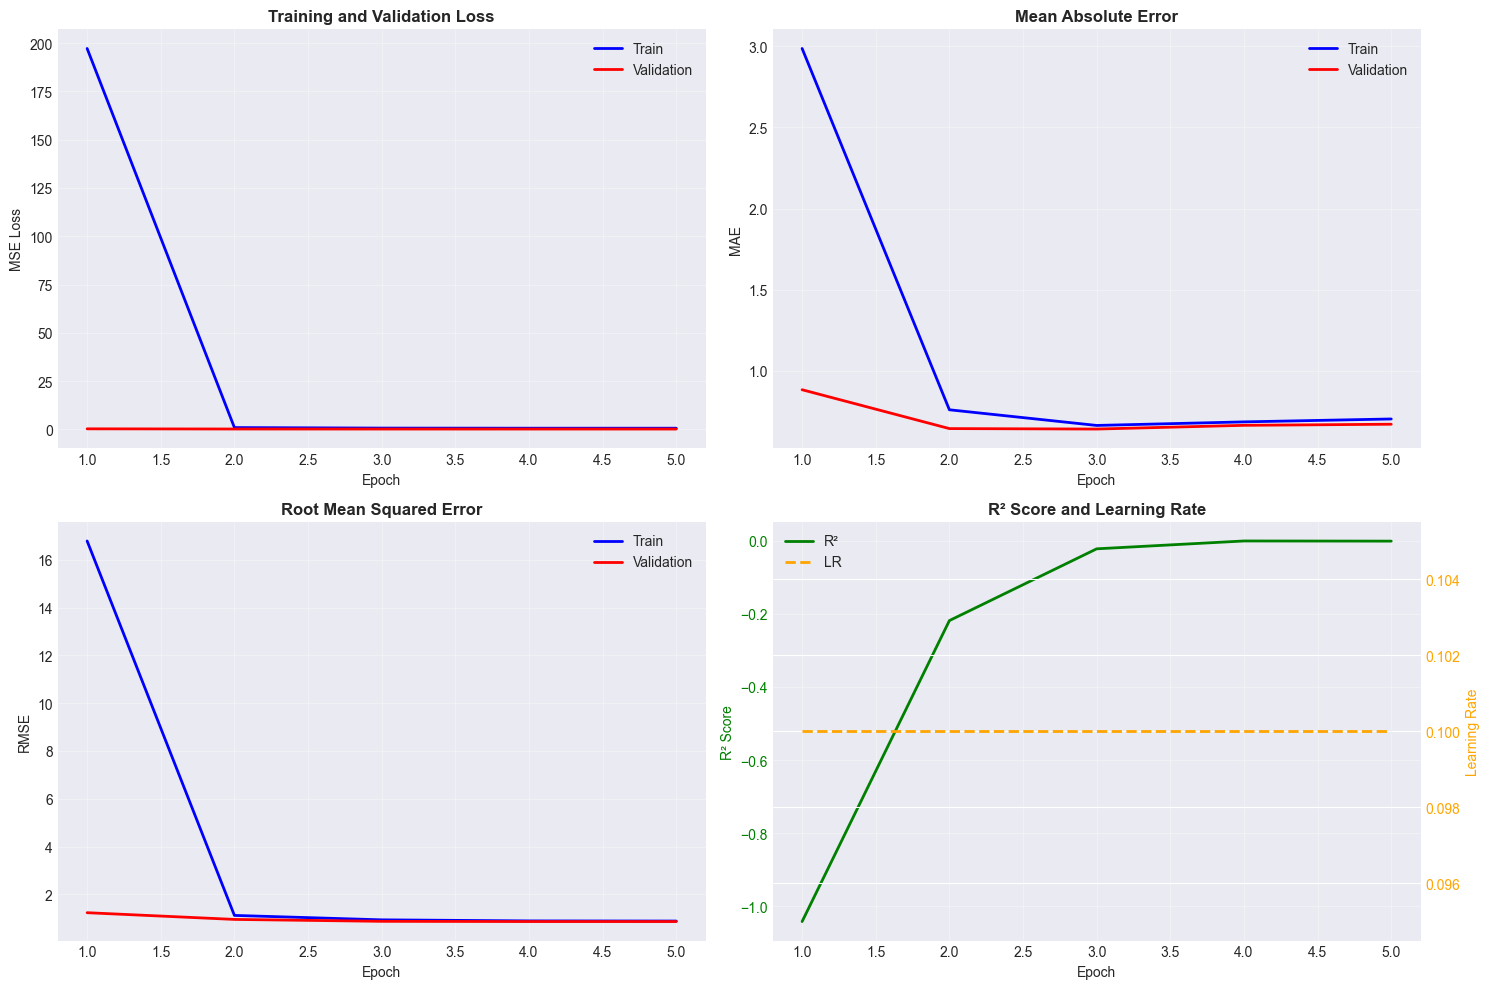

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training and Validation Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(epochs_range, history['train_mae'], 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_mae'], 'r-', label='Validation', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Mean Absolute Error', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# RMSE
axes[1, 0].plot(epochs_range, history['train_rmse'], 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_rmse'], 'r-', label='Validation', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('Root Mean Squared Error', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# R² and LR
ax1 = axes[1, 1]
ax2 = ax1.twinx()
line1 = ax1.plot(epochs_range, history['val_r2'], 'g-', label='R²', linewidth=2)
line2 = ax2.plot(epochs_range, history['learning_rate'], 'orange', label='LR', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('R² Score', color='g')
ax2.set_ylabel('Learning Rate', color='orange')
ax1.set_title('R² Score and Learning Rate', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='g')
ax2.tick_params(axis='y', labelcolor='orange')
ax1.grid(True, alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_progress.png'), dpi=300, bbox_inches='tight')
plt.show()



## Part 10: Test Set Evaluation

In [11]:
print("=" * 80)
print("Evaluating on Test Set")
print("=" * 80)

test_loss, test_mae, test_rmse, test_r2, test_preds, test_targets, test_cif_ids = validate_epoch(
    model, test_loader, criterion, device
)

print(f"\n📊 Test Set Performance:")
print(f"   Loss (MSE): {test_loss:.6f}")
print(f"   MAE:        {test_mae:.6f}")
print(f"   RMSE:       {test_rmse:.6f}")
print(f"   R² Score:   {test_r2:.4f}")

# Save results
test_results = pd.DataFrame({
    'material_id': test_cif_ids,
    'true_value': test_targets,
    'predicted_value': test_preds,
    'error': np.array(test_targets) - np.array(test_preds),
    'abs_error': np.abs(np.array(test_targets) - np.array(test_preds))
})

test_results_sorted = test_results.sort_values('abs_error', ascending=False)
test_results.to_csv(os.path.join(OUTPUT_DIR, 'test_results.csv'), index=False)

print(f"\n📋 Top 5 Best Predictions:")
print(test_results_sorted.tail(5)[['material_id', 'true_value', 'predicted_value', 'abs_error']])

print(f"\n⚠️ Top 5 Worst Predictions:")
print(test_results_sorted.head(5)[['material_id', 'true_value', 'predicted_value', 'abs_error']])



Evaluating on Test Set


Validation:   0%|                                                                                                              | 0/19 [00:00<?, ?it/s]C:\Users\Prabhat\Documents\Semester 7\CO4015 - Mini Project\cgcnn\.venv\Lib\site-packages\pymatgen\core\structure.py:3117: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Validation:   5%|████▋                                                                                     | 1/19 [00:00<00:02,  7.89it/s, loss=0.984]C:\Users\Prabhat\Documents\Semester 7\CO4015 - Mini Project\cgcnn\.venv\Lib\site-packages\pymatgen\core\structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Validation:  21%|██████████████████▉                     


📊 Test Set Performance:
   Loss (MSE): 0.132961
   MAE:        0.719154
   RMSE:       0.941492
   R² Score:   -0.0015

📋 Top 5 Best Predictions:
   material_id  true_value  predicted_value  abs_error
43  mp-1196199   -0.825077        -0.862137   0.037060
8    mp-560342   -0.893118        -0.862137   0.030981
38  mp-1018033   -0.873956        -0.862137   0.011819
56   mp-571623   -0.872663        -0.862137   0.010526
89  mp-1214992   -0.855050        -0.862137   0.007087

⚠️ Top 5 Worst Predictions:
    material_id  true_value  predicted_value  abs_error
139   mp-977360   -4.463333        -0.862137   3.601196
144    mp-30273   -3.586422        -0.862137   2.724285
126    mp-28503   -3.337936        -0.862137   2.475799
1     mp-758571   -3.308075        -0.862137   2.445938
59    mp-757333   -3.303875        -0.862137   2.441738


## Part 11: Prediction Analysis Visualizations

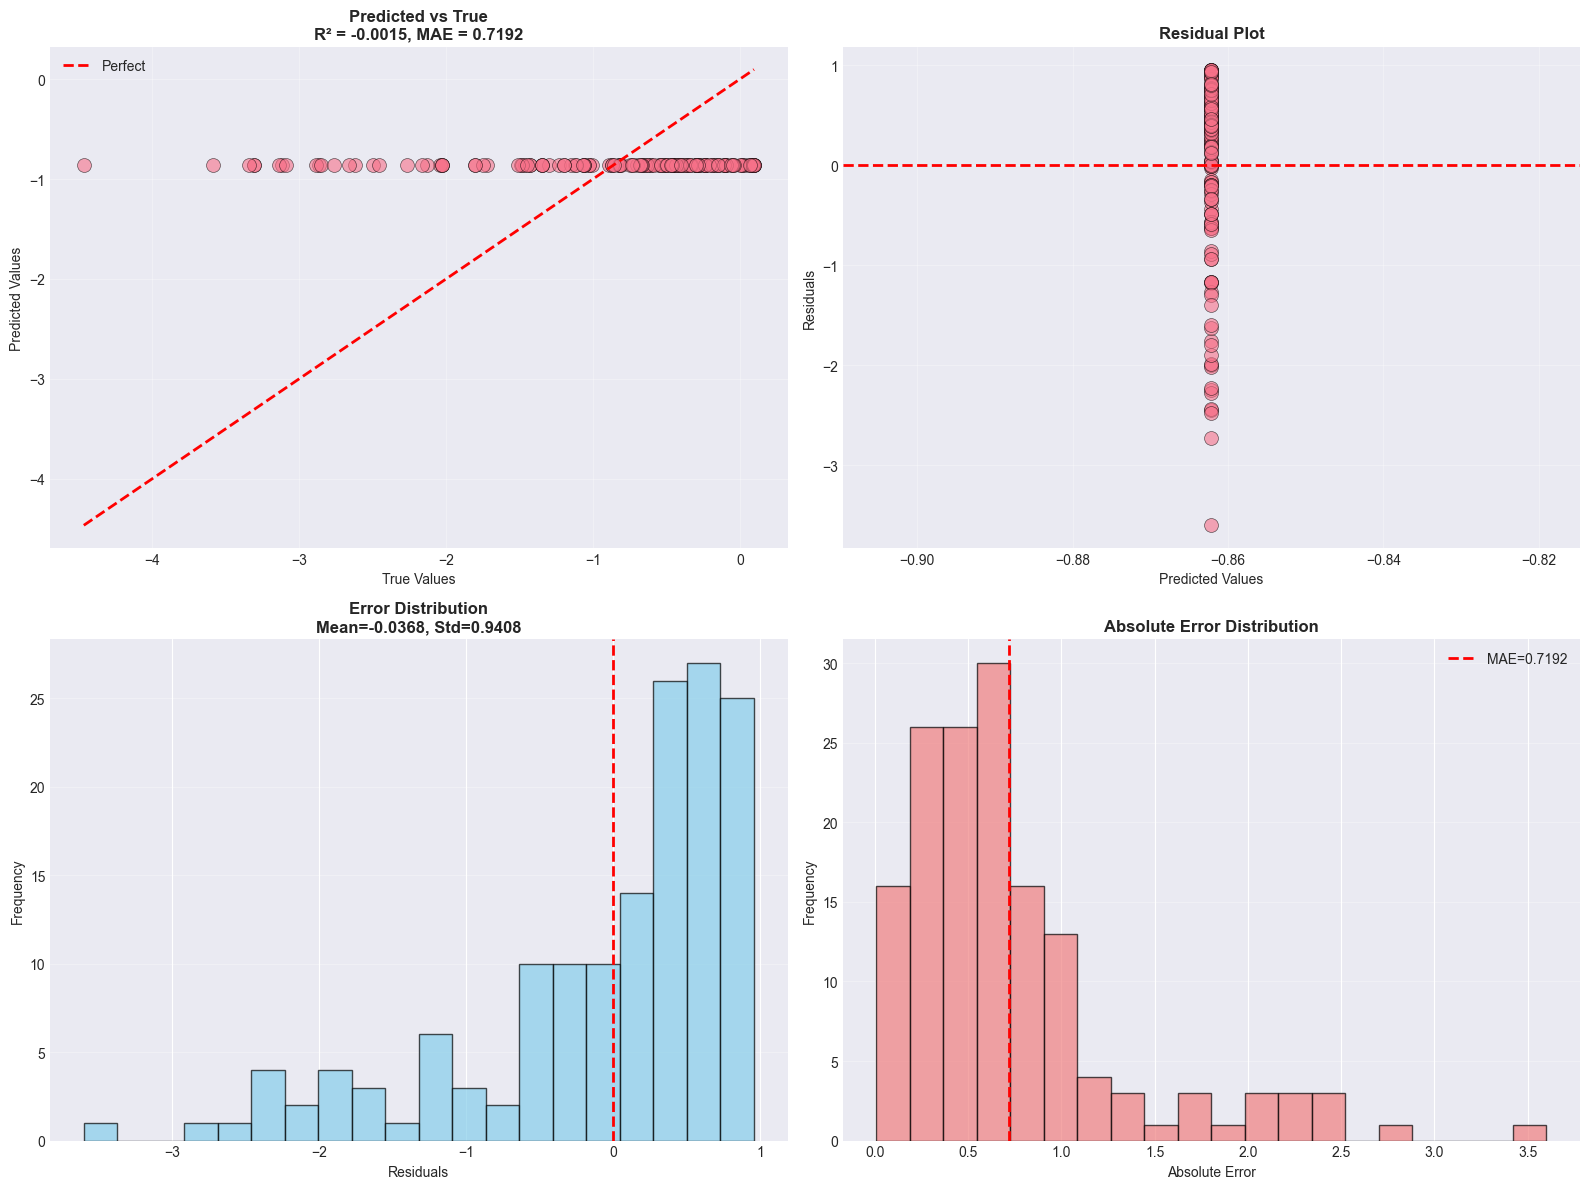

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Predicted vs True
axes[0, 0].scatter(test_targets, test_preds, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[0, 0].plot([min(test_targets), max(test_targets)], [min(test_targets), max(test_targets)], 
                'r--', linewidth=2, label='Perfect')
axes[0, 0].set_xlabel('True Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title(f'Predicted vs True\nR² = {test_r2:.4f}, MAE = {test_mae:.4f}', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals
residuals = np.array(test_targets) - np.array(test_preds)
axes[0, 1].scatter(test_preds, residuals, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Error distribution
axes[1, 0].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Error Distribution\nMean={np.mean(residuals):.4f}, Std={np.std(residuals):.4f}', 
                     fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Absolute error
abs_errors = np.abs(residuals)
axes[1, 1].hist(abs_errors, bins=20, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1, 1].axvline(x=test_mae, color='r', linestyle='--', linewidth=2, label=f'MAE={test_mae:.4f}')
axes[1, 1].set_xlabel('Absolute Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Absolute Error Distribution', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()



## Summary

✅ **Training Complete!**

All results have been saved to the `training_results/` directory:
- `best_model.pth`: Best model checkpoint
- `training_history.csv`: Training metrics over epochs
- `test_results.csv`: Detailed test predictions
- `performance_summary.csv`: Final metrics summary
- `training_progress.png`: Training curves
- `prediction_analysis.png`: Prediction visualizations
- `performance_comparison.png`: Performance comparison

---

**Next Steps:**
1. Analyze error patterns in worst predictions
2. Try hyperparameter tuning
3. Experiment with different architectures
4. Use the trained model for predictions on new materials